In [1]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [2]:
sys.path.append("/nfs/home/aoku/software/miniconda3/lib/python3.11/site-packages")

In [3]:
def plot_true_vs_predicted(true_proportions, predicted_proportions, n_cols=6, figsize_per_plot=(3, 3), dot_size=10, save_path=""):

    # Get column names (cell types or lineages)
    cols = predicted_proportions.columns
    n_rows = int(np.ceil(len(cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * figsize_per_plot[0], n_rows * figsize_per_plot[1]))
    axes = axes.flatten()

    # cat = np.where(true_proportions.index.str.startswith("Mix"), 
    #                       "Mixture", 
    #                       "Homogeneous")

    for i, col in enumerate(cols):
        ax = axes[i]
        x = true_proportions[col]
        y = predicted_proportions[col]

        # Scatterplot
        sns.scatterplot(x=x, y=y, alpha=0.7, ax=ax, s=dot_size)

        # Identity line
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--')

        # Correlation coefficient
        corr, _ = pearsonr(x, y)
        ax.text(
            0.05, 0.95, f"r = {corr:.2f}",
            transform=ax.transAxes,
            verticalalignment='top',
            fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.5)
        )

        # Titles and labels
        ax.set_title(f'{col}')
        ax.set_xlabel('True')
        ax.set_ylabel('Predicted')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.savefig(save_path, dpi=600, bbox_inches='tight', transparent=False)
    plt.tight_layout()
    plt.show()


In [4]:
# Load ground truth
true_prop = pd.read_csv("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/GSE220608/cell_lines_mixture_goundtruth.csv",
                       index_col=0)

In [5]:
true_prop = true_prop.replace('%', '', regex=True).astype(float).astype(int)
true_prop = true_prop/100

In [6]:
true_prop = true_prop[true_prop.index.str.startswith("Mix")]

In [7]:
true_prop.head()

,Jurkat,Thp1,BT474,MCF7,T47D,hMSC
Mix1_a,0.10,0.05,0.16,0.02,0.66,0.00
Mix1_b,0.10,0.05,0.16,0.02,0.66,0.00
Mix1_c,0.10,0.05,0.16,0.02,0.66,0.00
Mix2_a,0.05,0.10,0.62,0.13,0.08,0.01
Mix2_b,0.05,0.10,0.62,0.13,0.08,0.01


In [8]:
# Load results
# predicted_bulk = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data_cell_lines/metrics_bulk/c2s_output_test_predictions.csv",
#                             index_col=0)

In [9]:
# predicted_bulk = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data_cell_lines/metrics_bulk_nnls/counts_output_test_predictions.csv",
#                       index_col=0)

In [10]:
predicted_bulk = pd.read_csv("/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data_cell_lines/metrics_nnls/gf_nnls_cell_proportions_bulk_cell_lines.csv", 
                            index_col=0)

predicted_bulk.columns = predicted_bulk.columns.str.replace('_1$', '', regex=True)

In [11]:
predicted_bulk = predicted_bulk.loc[true_prop.index, ]

In [12]:
predicted_bulk

,BT474,T47D,MCF7,Thp1,Jurkat,hMSC
Mix1_a,0.237091,0.572862,0.000000,0.000000,0.094839,0.095208
Mix1_b,0.273663,0.598979,0.086320,0.036333,0.000000,0.004704
Mix1_c,0.295621,0.586577,0.074233,0.016078,0.027491,0.000000
Mix2_a,0.785375,0.029217,0.110092,0.000000,0.043802,0.031513
Mix2_b,0.750532,0.100325,0.042333,0.000000,0.069378,0.037431
Mix2_c,0.649489,0.064163,0.146393,0.139955,0.000000,0.000000
Mix3_a,0.394106,0.339135,0.193735,0.060457,0.000000,0.012566
Mix3_b,0.332207,0.346653,0.217339,0.095113,0.000000,0.008688
Mix3_c,0.384099,0.351379,0.194746,0.026446,0.023136,0.020194
Mix4_a,0.442808,0.254118,0.219048,0.070352,0.007422,0.006252


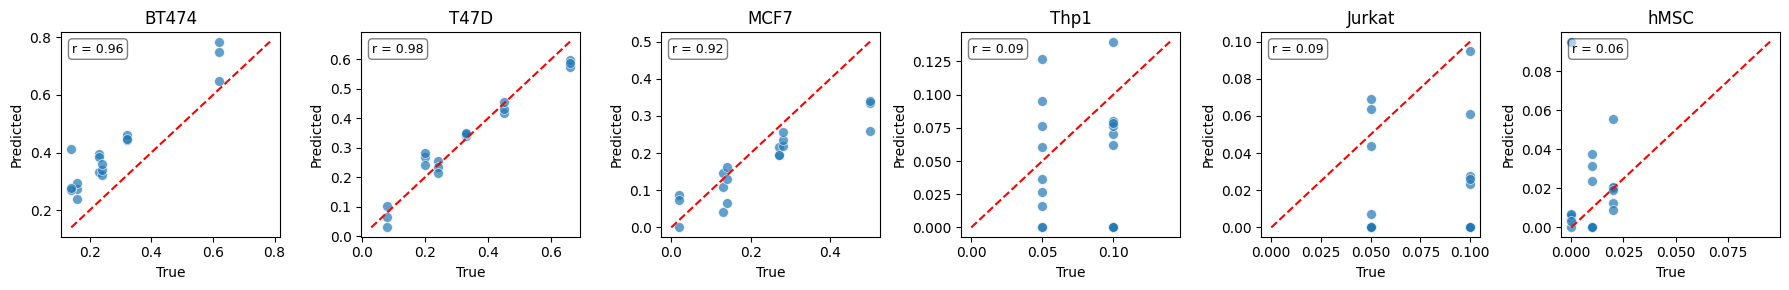

In [13]:
plot_true_vs_predicted(true_proportions=true_prop, predicted_proportions=predicted_bulk, dot_size=50)

In [40]:
rmse = np.sqrt(((true_prop - predicted_bulk)**2).mean().mean())

In [41]:
rmse

0.07828830803332053

In [48]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(true_prop, predicted_bulk))

In [49]:
rmse

0.28011916224002004